In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_data_v4.csv")

In [5]:
df["description_bin"].unique()

<StringArray>
['Pillar', 'Mount', 'Plate', 'Beam', 'Bracket', 'Nut', 'Rail', 'Panel']
Length: 8, dtype: str

In [6]:
# Passing Weights to each description based on complexity of conversion process.
# Higher Weights -> More Conversion Complexity
# Lower Weights -> Lower Conversion Complexity

In [21]:
def get_category(df: pd.DataFrame, category_name: str):
    return df.loc[df["category"] == category_name]

In [24]:
get_category(df, category_name="Mount")

,part_id,part_description,supplier_name,plant_location,category,material_type,material_grade,unit_weight_kg,annual_volume,unit_price_local,...,per_kg_price,material_grade_clean,price_low_per_kg,price_base_per_kg,price_high_per_kg,confidence,source,material_cost_low,material_cost_base,material_cost_high
37,PART-0045,Engine Mount Bracket,Om Precision Tools,Chennai,Mount,Steel,dp780,1.730,24000,167.89,...,97.046243,DP780,75,81.5,88,Medium,IndiaMART / market benchmark,129.75,140.995,152.240
50,PART-0010,Chassis Mount Bracket,Om Precision Tools,Gurugram,Mount,Steel,DP780,1.704,5000,180.37,...,105.850939,DP780,75,81.5,88,Medium,IndiaMART / market benchmark,127.80,138.876,149.952


In [28]:
df.loc[df["category"] == "Mount", "category"] = "Brackets & Mounts"

In [29]:
df["category"].value_counts()

category
Brackets & Mounts    53
Body Panels          22
Fasteners            15
Reinforcements       13
Rail                  8
Plate                 3
Beam                  1
Nut                   1
brackets              1
Name: count, dtype: int64

In [32]:
df.loc[df["category"] == "brackets", "category"] = "Plate"


In [33]:
df["category"].value_counts()

category
Brackets & Mounts    53
Body Panels          22
Fasteners            15
Reinforcements       13
Rail                  8
Plate                 4
Beam                  1
Nut                   1
Name: count, dtype: int64

In [38]:
df.loc[df["category"] == "Beam", "category"] = "Reinforcements"


In [39]:
df["category"].value_counts()

category
Brackets & Mounts    53
Body Panels          22
Fasteners            15
Reinforcements       14
Rail                  8
Plate                 4
Nut                   1
Name: count, dtype: int64

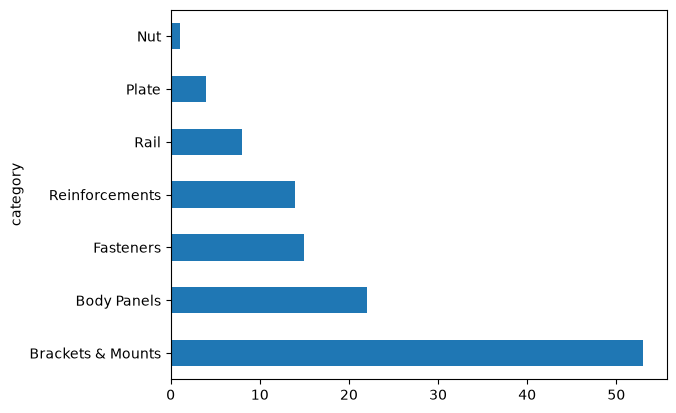

In [46]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="barh")
plt.show()

In [47]:
df["category"].value_counts()

category
Brackets & Mounts    53
Body Panels          22
Fasteners            15
Reinforcements       14
Rail                  8
Plate                 4
Nut                   1
Name: count, dtype: int64

In [48]:
df["Condensed_Category_Description"] = ""
df["Condensed_Category"] = ""

In [51]:
df.loc[
    df["category"].isin(["Brackets & Mounts", "Reinforcements", "Rail"]),
    "Condensed_Category",
] = "Structural Formed Components"

In [52]:
df.loc[
    df["category"].isin(["Brackets & Mounts", "Reinforcements", "Rail"]),
    "Condensed_Category_Description",
] = "All are generally structural/form-formed components and likely have meaningful forming/conversion effort"

In [58]:
df.loc[
    df["category"].isin(["Fasteners", "Nut"]),
    ["Condensed_Category_Description", "Condensed_Category"],
] = [
    "Both are hardware rather than large sheet-metal structural components",
    "Hardware",
]


In [59]:
df.loc[
    df["category"] == "Plate",
    ["Condensed_Category_Description", "Condensed_Category"],
] = [
    "Keep separate because plates are generally simpler blanking/cutting/forming components",
    "Plates",
]


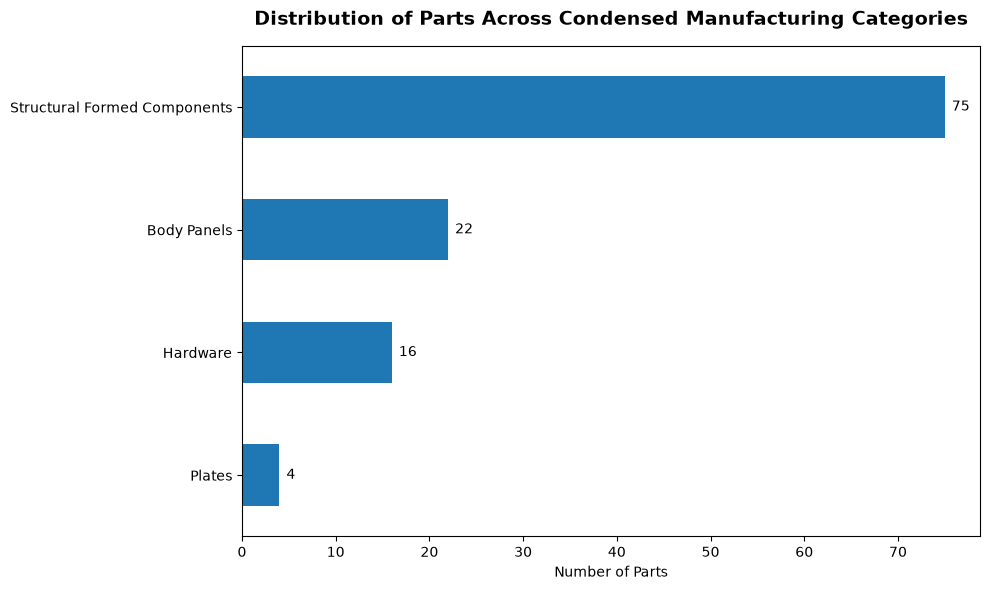

In [74]:
ax = (
    df["Condensed_Category"]
    .value_counts()
    .sort_values(ascending=True)
    .plot(kind="barh", figsize=(10, 6))
)

ax.set_title(
    "Distribution of Parts Across Condensed Manufacturing Categories",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Number of Parts")
ax.set_ylabel("Condensed Category")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=5)
plt.ylabel("")
plt.tight_layout()
plt.savefig("Condensed_Categories.png")


In [75]:
df.to_csv("cleaned_data_v5.csv", index=False)

In [82]:
complexity_mapping = {
    "Structural Formed Components": {
        "weight": 0.35,
        "relative_sensitivity": 1.75,
    },
    "Body Panels": {
        "weight": 0.30,
        "relative_sensitivity": 1.50,
    },
    "Plates": {
        "weight": 0.20,
        "relative_sensitivity": 1.00,
    },
    "Hardware": {
        "weight": 0.15,
        "relative_sensitivity": 0.75,
    },
}


In [83]:
df["Complexity_Weight"] = df["Condensed_Category"].map(
    lambda x: complexity_mapping[x]["weight"]
)

df["Relative_Complexity"] = df["Condensed_Category"].map(
    lambda x: complexity_mapping[x]["relative_sensitivity"]
)

### Baseline Complexity  = 1.00 for Plates.

In [86]:
df.select_dtypes(include="number").columns

Index(['unit_weight_kg', 'annual_volume', 'unit_price_local', 'spend',
       'per_kg_price', 'price_low_per_kg', 'price_base_per_kg',
       'price_high_per_kg', 'material_cost_low', 'material_cost_base',
       'material_cost_high', 'Complexity_Weight', 'Relative_Complexity'],
      dtype='str')

### Assumptions

In [88]:
COST_ASSUMPTIONS = {
    "press_rate_per_hour": {
        "low": 150,
        "base": 225,
        "high": 300,
    },
    "operator_labor_per_hour": {
        "low": 250,
        "base": 350,
        "high": 450,
    },
    "effective_utilization": {
        "low": 0.85,
        "base": 0.825,
        "high": 0.80,
    },
    "tooling_investment": {
        "low": 5_000,
        "base": 20_000,
        "high": 50_000,
    },
}

In [89]:
PRESS_RATE = COST_ASSUMPTIONS["press_rate_per_hour"]
LABOR_RATE = COST_ASSUMPTIONS["operator_labor_per_hour"]
UTILIZATION = COST_ASSUMPTIONS["effective_utilization"]
TOOLING = COST_ASSUMPTIONS["tooling_investment"]

In [97]:
CYCLE_TIME_SEC = {
    "Hardware": {
        "low": 2,
        "base": 4,
        "high": 6,
    },
    "Plates": {
        "low": 3,
        "base": 5,
        "high": 8,
    },
    "Body Panels": {
        "low": 6,
        "base": 10,
        "high": 15,
    },
    "Structural Formed Components": {
        "low": 6,
        "base": 12,
        "high": 20,
    },
}

In [98]:
for scenario in ["low", "base", "high"]:
    df[f"cycle_time_{scenario}_sec"] = df["Condensed_Category"].map(
        {category: values[scenario] for category, values in CYCLE_TIME_SEC.items()}
    )

In [99]:
for scenario in ["low", "base", "high"]:
    df[f"press_cost_{scenario}"] = (df[f"cycle_time_{scenario}_sec"] / 3600) * (
        COST_ASSUMPTIONS["press_rate_per_hour"][scenario]
        / COST_ASSUMPTIONS["effective_utilization"][scenario]
    )

In [101]:
for scenario in ["low", "base", "high"]:
    df[f"labor_cost_{scenario}"] = (df[f"cycle_time_{scenario}_sec"] / 3600) * (
        COST_ASSUMPTIONS["operator_labor_per_hour"][scenario]
        / COST_ASSUMPTIONS["effective_utilization"][scenario]
    )

In [ ]:
for scenario in ["low", "base", "high"]:
    df[f"conversion_cost_{scenario}"] = (
        df[f"press_cost_{scenario}"] + df[f"labor_cost_{scenario}"]
    )

### Secondary Operation Flag

In [102]:
df["has_secondary_operation"] = df["part_description"].str.contains(
    "weld|assembly|assembled|riv|bolt",
    case=False,
    na=False,
)

### Further Assumptions

In [105]:
COST_ASSUMPTIONS.update(
    {
        "overhead_rate": {
            "low": 0.10,
            "base": 0.15,
            "high": 0.20,
        },
        "secondary_operation_rate": {
            "low": 0,
            "base": 50,
            "high": 100,
        },
    }
)

In [106]:
TOOLING = COST_ASSUMPTIONS["tooling_investment"]

In [107]:
for scenario in ["low", "base", "high"]:
    df[f"tooling_cost_{scenario}"] = TOOLING[scenario] / df["annual_volume"].clip(
        lower=1
    )

In [108]:
for scenario in ["low", "base", "high"]:
    df[f"overhead_cost_{scenario}"] = (
        df[f"press_cost_{scenario}"] + df[f"labor_cost_{scenario}"]
    ) * COST_ASSUMPTIONS["overhead_rate"][scenario]


In [109]:
secondary_pattern = (
    r"weld|assembly|assembled|riv|bolt|"
    r"adhesive|coating|paint"
)

df["has_secondary_operation"] = df["part_description"].str.contains(
    secondary_pattern,
    case=False,
    na=False,
)

In [110]:
for scenario in ["low", "base", "high"]:
    df[f"secondary_cost_{scenario}"] = (
        df["has_secondary_operation"].astype(int)
        * COST_ASSUMPTIONS["secondary_operation_rate"][scenario]
    )

In [111]:
for scenario in ["low", "base", "high"]:
    df[f"conversion_cost_{scenario}"] = (
        df[f"press_cost_{scenario}"]
        + df[f"labor_cost_{scenario}"]
        + df[f"tooling_cost_{scenario}"]
        + df[f"overhead_cost_{scenario}"]
        + df[f"secondary_cost_{scenario}"]
    )

In [112]:
for scenario in ["low", "base", "high"]:
    df[f"should_cost_{scenario}"] = (
        df[f"material_cost_{scenario}"] + df[f"conversion_cost_{scenario}"]
    )

In [116]:
df[["unit_price_local", "should_cost_base"]]

,unit_price_local,should_cost_base
0,79.56,49.229273
1,7.85,88.722908
2,108.00,80.745184
3,51.88,46.177384
4,101.47,74.615717
...,...,...
112,87.24,74.764717
113,90.84,62.414884
114,151.64,110.953051
115,122.59,100.032931
